# Graph Embedding

Try to get an embedding that incorporates both connectivity & firing rates

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd
import networkx as nx
from sklearn.metrics import pairwise_distances

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import connectivity_utils as cu
import bhv_utils as bhv
from bootstrap_method import *



In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = 150

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [4]:
# choose model 0 to visualize for now
model_name = model_dirs[1] # start w a good model
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645/neuraldata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645/bhvdata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645/timingdata_raw_delay150.mat']


In [5]:
# neural data
importlib.reload(ld)
lfp_data, spk_times_df, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=False, load_spikes=False, load_rates=True)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay)
times_ms, _,_ = ld.get_times_dict('ds', condn_phrase, condn_num, model_name)

# get connectivity info
connectivity_df = ld.get_connectivity_df(model_name)

In [6]:
# restructure rate data

# get matrix of just mean firing rate for each neuron for each trial type (time x neurons x 4 trial types)
stim1_on = int(times_ms['stim1_on'])

t = int(rates_data.shape[0] - stim1_on)
rates_mean = np.zeros((t, rates_data.shape[1], 4))
trialtype_idxs = np.zeros((t*4))
trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)
for i, trial_type in enumerate(trial_types):
    trials_idx = (trial_idxs == i)
    trialtype_idxs[i*t:(i+1)*t] = i
    # get mean rate
    rates_mean[:,:, i] = np.mean(rates_data[stim1_on:, :, trials_idx], axis=2)

print(rates_mean.shape)
print(trialtype_idxs.shape)

# concatenate 4 trial types one after another in time
rates_mean = rates_mean.transpose(2,0,1).reshape(-1, rates_mean.shape[1])
print(rates_mean.shape, trialtype_idxs.shape)

N = rates_mean.shape[1]

(1900, 200, 4)
(7600,)
(7600, 200) (7600,)


In [7]:
# get graph weights

W = ld.get_weights(model_name)
W.shape

(200, 200)

In [8]:
def get_rate_features(r, normalize=True):
    if normalize:
        r = (r - r.mean(axis=1, keepdims=True)) / (r.std(axis=1, keepdims=True) + 1e-8)
    return r  # shape (200, T)


In [9]:
importlib.reload(cu)
G = cu.build_directed_graph(W)
L = cu.compute_graph_laplacian_signed(G)

rate_features = get_rate_features(rates_mean.T)

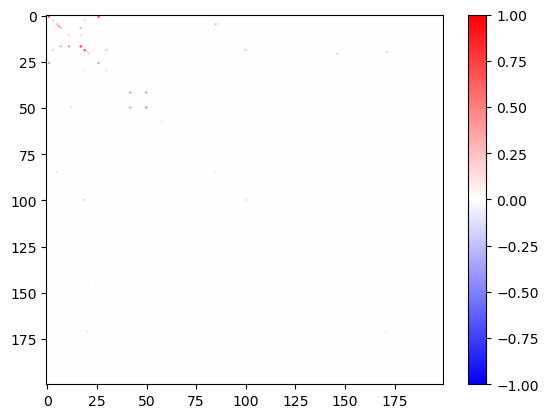

In [10]:
graph_dist = L.copy()
graph_dist[graph_dist == np.inf] = np.max(graph_dist[graph_dist != np.inf])
graph_dist /= np.max(graph_dist)

plt.imshow(graph_dist, aspect='auto', cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()

In [11]:
def combined_distance(rate_features, graph_distances, alpha=0.5):
    # Normalize distances
    rate_dist = pairwise_distances(rate_features, metric='euclidean')
    rate_dist /= np.max(rate_dist)
    graph_dist = graph_distances.copy()
    graph_dist[graph_dist == np.inf] = np.max(graph_dist[graph_dist != np.inf])
    graph_dist /= np.max(graph_dist)

    combined = alpha * rate_dist + (1 - alpha) * graph_dist
    return combined


In [12]:
from umap import UMAP

def embed_umap(dist_matrix, dim=2):
    umap = UMAP(n_components=dim, random_state=42)
    embedding = umap.fit_transform(dist_matrix)
    return embedding

2025-05-08 10:50:31.804975: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-08 10:50:31.811538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-08 10:50:31.818032: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-08 10:50:31.819980: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-08 10:50:31.825764: I tensorflow/core/platform/cpu_feature_guar

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


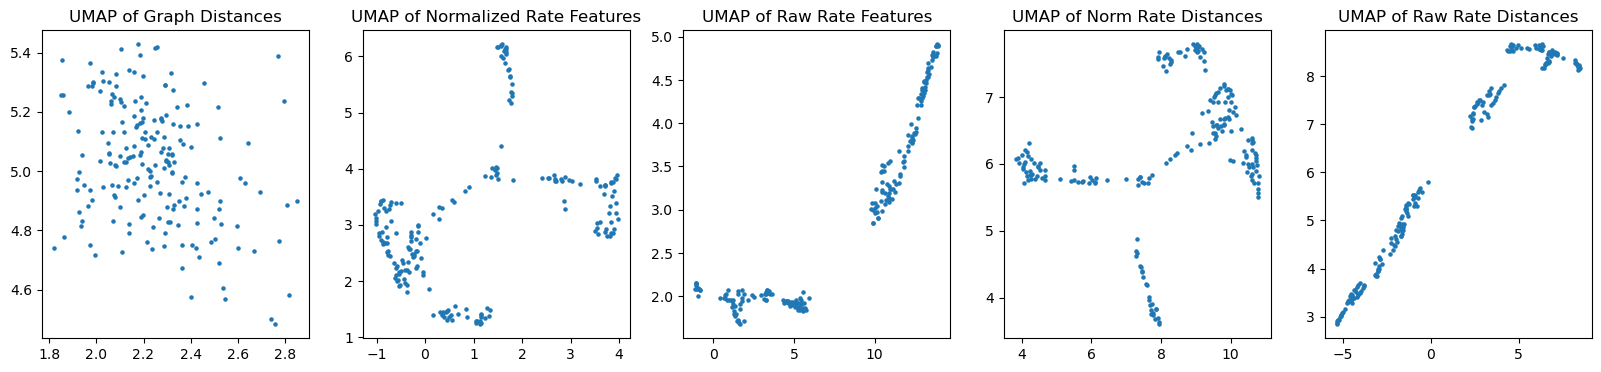

In [16]:
from sklearn.metrics import pairwise_distances
rate_dist_norm = pairwise_distances(rate_features, metric='euclidean')
rate_dist_norm /= np.max(rate_dist_norm)
rate_dist_raw = pairwise_distances(rates_mean.T, metric='euclidean')
rate_dist_raw /= np.max(rate_dist_raw)
dist_matrix_norm = combined_distance(rate_features, L, alpha=0.5)
dist_matrix_raw = combined_distance(rates_mean.T, L, alpha=0.5)
graph_dist = L.copy()
graph_dist[graph_dist == np.inf] = np.max(graph_dist[graph_dist != np.inf])

embedding_dist = embed_umap(graph_dist, dim=20)
embedding_norm = embed_umap(dist_matrix_norm, dim=20)
embedding_raw = embed_umap(dist_matrix_raw, dim=20)
embedding_rate_norm = embed_umap(rate_dist_norm, dim=20)
embedding_rate_raw = embed_umap(rate_dist_raw, dim=20)

fig, axs = plt.subplots(1, 5, figsize=(20, 4)) 
axs[0].scatter(embedding_dist[:, 0], embedding_dist[:, 1], s=5)
axs[0].set_title('UMAP of Graph Distances')
axs[1].scatter(embedding_norm[:, 0], embedding_norm[:, 1], s=5)
axs[1].set_title('UMAP of Normalized Rate Features')
axs[2].scatter(embedding_raw[:, 0], embedding_raw[:, 1], s=5)
axs[2].set_title('UMAP of Raw Rate Features')
axs[3].scatter(embedding_rate_norm[:, 0], embedding_rate_norm[:, 1], s=5)
axs[3].set_title('UMAP of Norm Rate Distances')
axs[4].scatter(embedding_rate_raw[:, 0], embedding_rate_raw[:, 1], s=5)
axs[4].set_title('UMAP of Raw Rate Distances')
plt.show()

In [14]:
exc_ind, inh_ind = ld.get_celltype_label(model_name)
exc = np.zeros(N)
exc[exc_ind] = 1

In [15]:
importlib.reload(sn)
tuning = sn.calc_stim1_tuning(model_name, condn_phrase, condn_num, rates_data=rates_data)
# replace nan's with zeros
tuning[np.isnan(tuning)] = 0

In [19]:
def plot_embedding_exc_tuning(embedding, exc, tuning, title):
    fig, axs = plt.subplots(1, 2, figsize=(8,4))
    colors = [exc, tuning]
    titles = ["Exc/Inh", "Tuning"]
    for i, ax in enumerate(axs):
        sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=colors[i], s=30)
        ax.set_title(titles[i])
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")
        # fig.colorbar(sc, ax=ax)

    # add colorbar labels
    cbar = fig.colorbar(sc, ax=axs[0])
    cbar.set_ticks([-1, 1])
    cbar.set_ticklabels(['inh', 'exc'])
    cbar = fig.colorbar(sc, ax=axs[1])
    cbar.set_ticks([-1, 0, 1])
    cbar.set_ticklabels(['pref +1','no pref','pref -1'])

    plt.suptitle(f"Neuron UMAP Embedding, {title}")
    plt.tight_layout()
    plt.show()

In [46]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def plot_kmeans_clusters(embedding, title):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    scores = []
    for k in range(2,10):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(embedding)
        labels = kmeans.labels_
        score = silhouette_score(embedding, labels)
        scores.append(score)
        best_k = k if (score == max(scores)) else best_k
    axs[0].plot(range(2,10), scores)
    axs[0].axvline(x=best_k, color='r', linestyle='--')
    axs[0].set_title("Silhouette Score vs. Number of Clusters")
    axs[0].set_xlabel("Number of Clusters")
    axs[0].set_ylabel("Silhouette Score")
    axs[0].grid(True)

    kmeans = KMeans(n_clusters=best_k, random_state=42)
    kmeans.fit(embedding)
    labels = kmeans.labels_
    scatter = axs[1].scatter(embedding[:, 0], embedding[:, 1], c=labels, s=30)
    axs[1].set_title(f"KMeans Clustering on {title} Embedding")
    axs[1].set_xlabel("Dim 1")
    axs[1].set_ylabel("Dim 2")
    axs[1].grid(True)
    plt.colorbar(scatter)
    plt.show()

    return best_k, labels

In [38]:
def plot_rates_by_cluster(model_name, condn_phrase, condn_num, labels, rates_data = rates_data):
    sort = np.argsort(labels)
    _, hlines = np.unique(np.sort(labels), return_index=True)
    sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, rates_data = rates_data, cut_off=50, sort=sort, hlines=hlines)
    # now with normalization (subtract baseline)
    sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, rates_data = rates_data, cut_off=50, sort=sort, normalize=True,
                                hlines = hlines)

In [ ]:
embedding_dist = embed_umap(graph_dist, dim=20)
embedding_norm = embed_umap(dist_matrix_norm, dim=20)
embedding_raw = embed_umap(dist_matrix_raw, dim=20)
embedding_rate_norm = embed_umap(rate_dist_norm, dim=20)
embedding_rate_raw = embed_umap(rate_dist_raw, dim=20)

### Embedding dist (graph dist only)

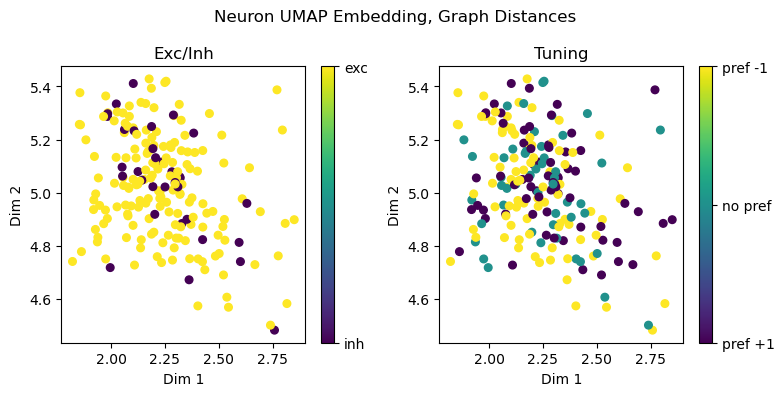

In [20]:
plot_embedding_exc_tuning(embedding_dist, exc, tuning, "Graph Distances")

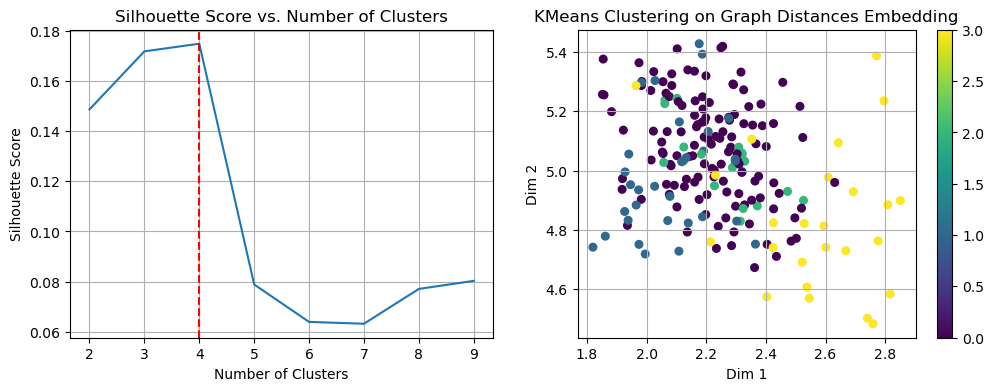

In [47]:
best_k, labels = plot_kmeans_clusters(embedding_dist, "Graph Distances")

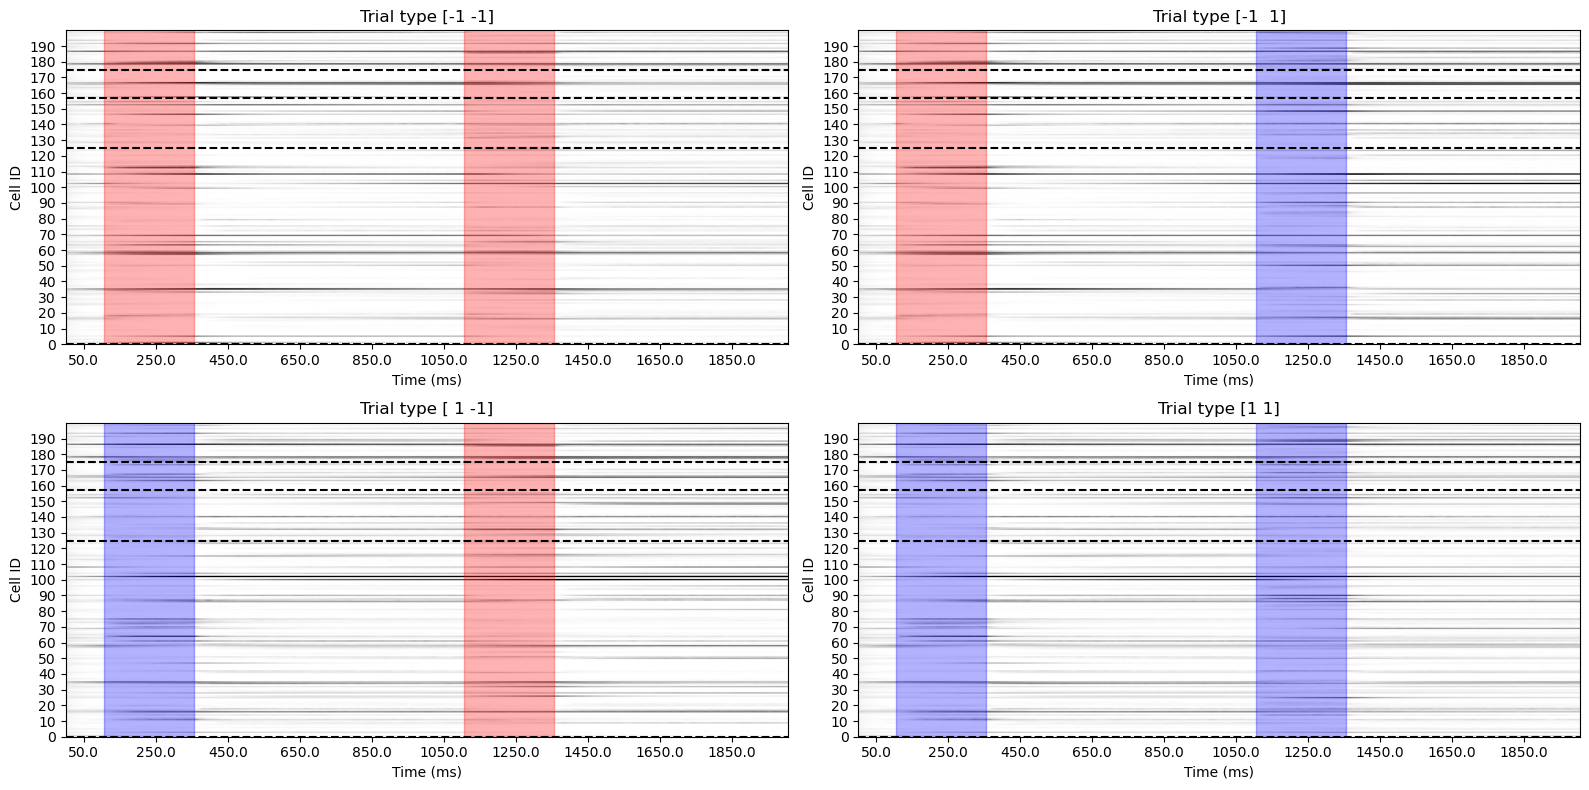

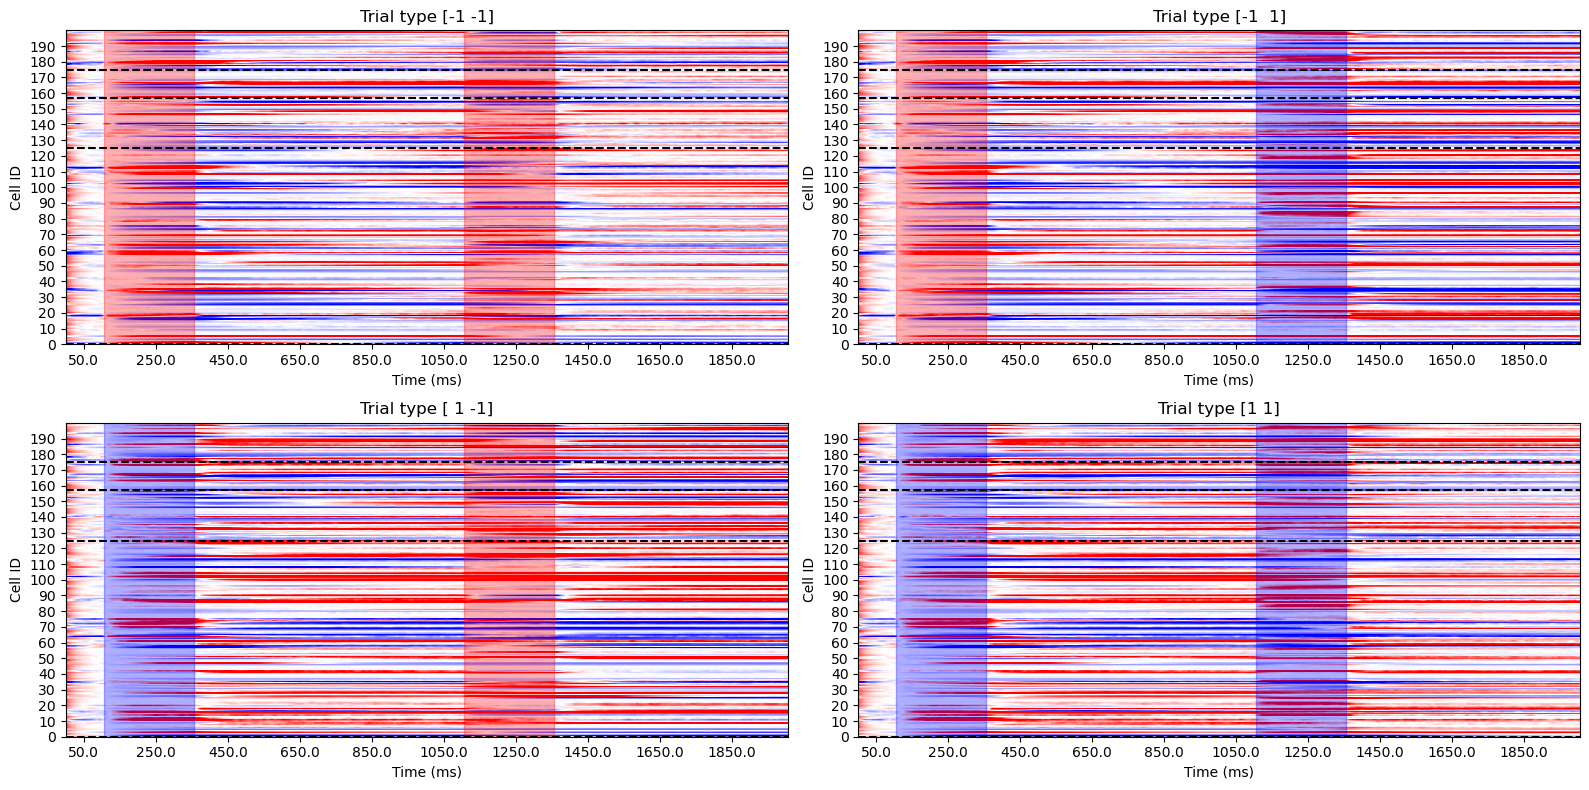

In [48]:
plot_rates_by_cluster(model_name, condn_phrase, condn_num, labels, rates_data = rates_data)

### Embedding norm (graph dist + normalized rate dist)

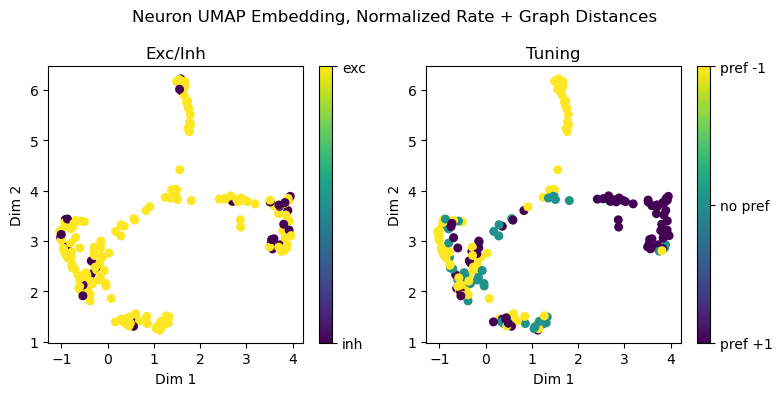

In [24]:
plot_embedding_exc_tuning(embedding_norm, exc, tuning, "Normalized Rate + Graph Distances")

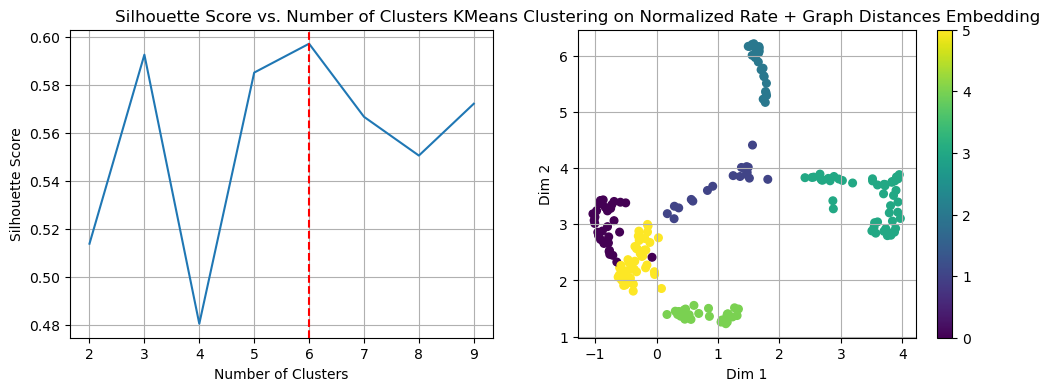

In [49]:
best_k, labels = plot_kmeans_clusters(embedding_norm, "Normalized Rate + Graph Distances")

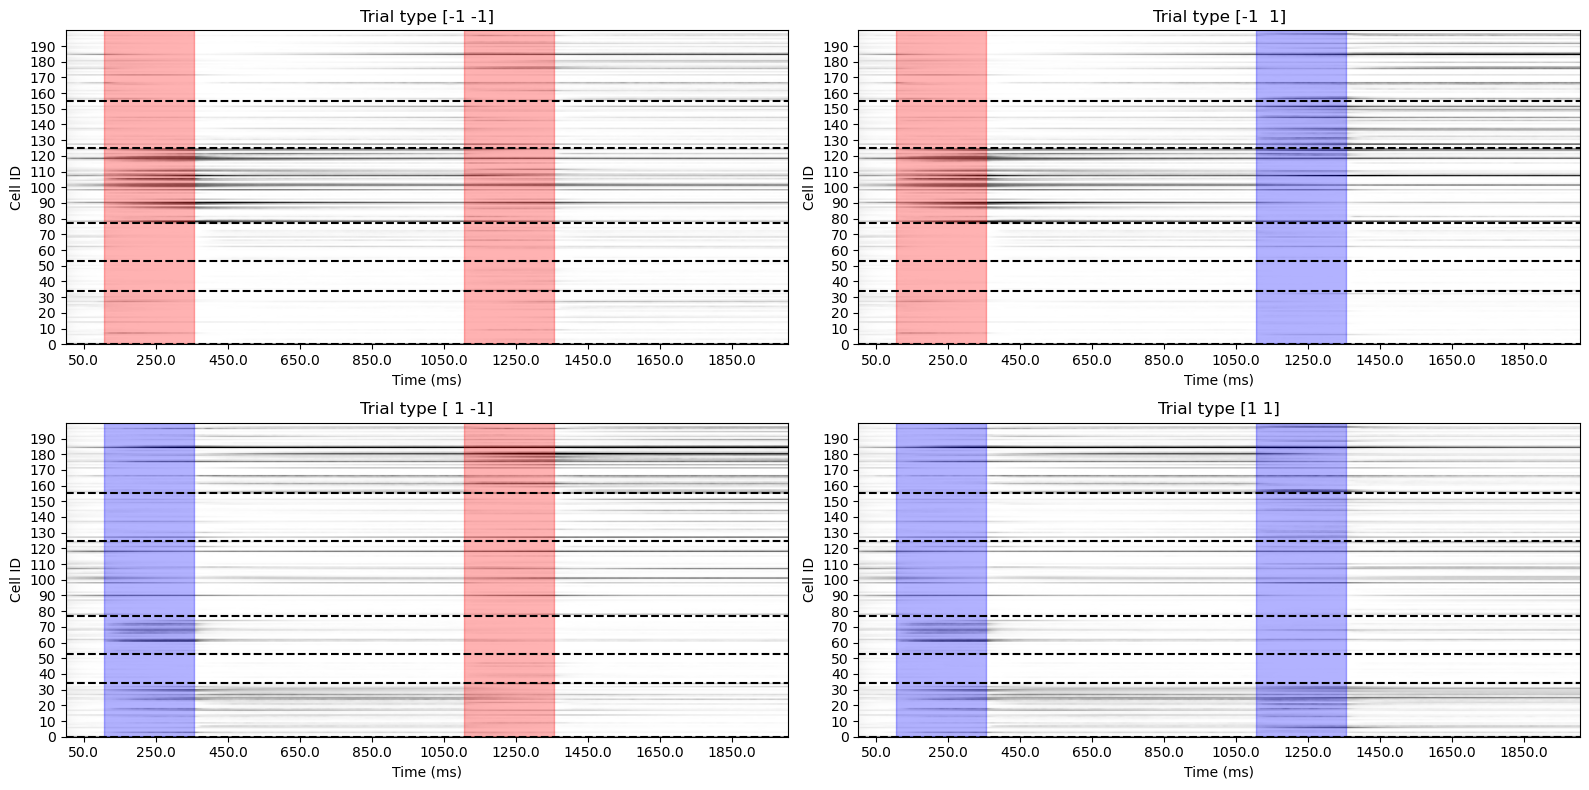

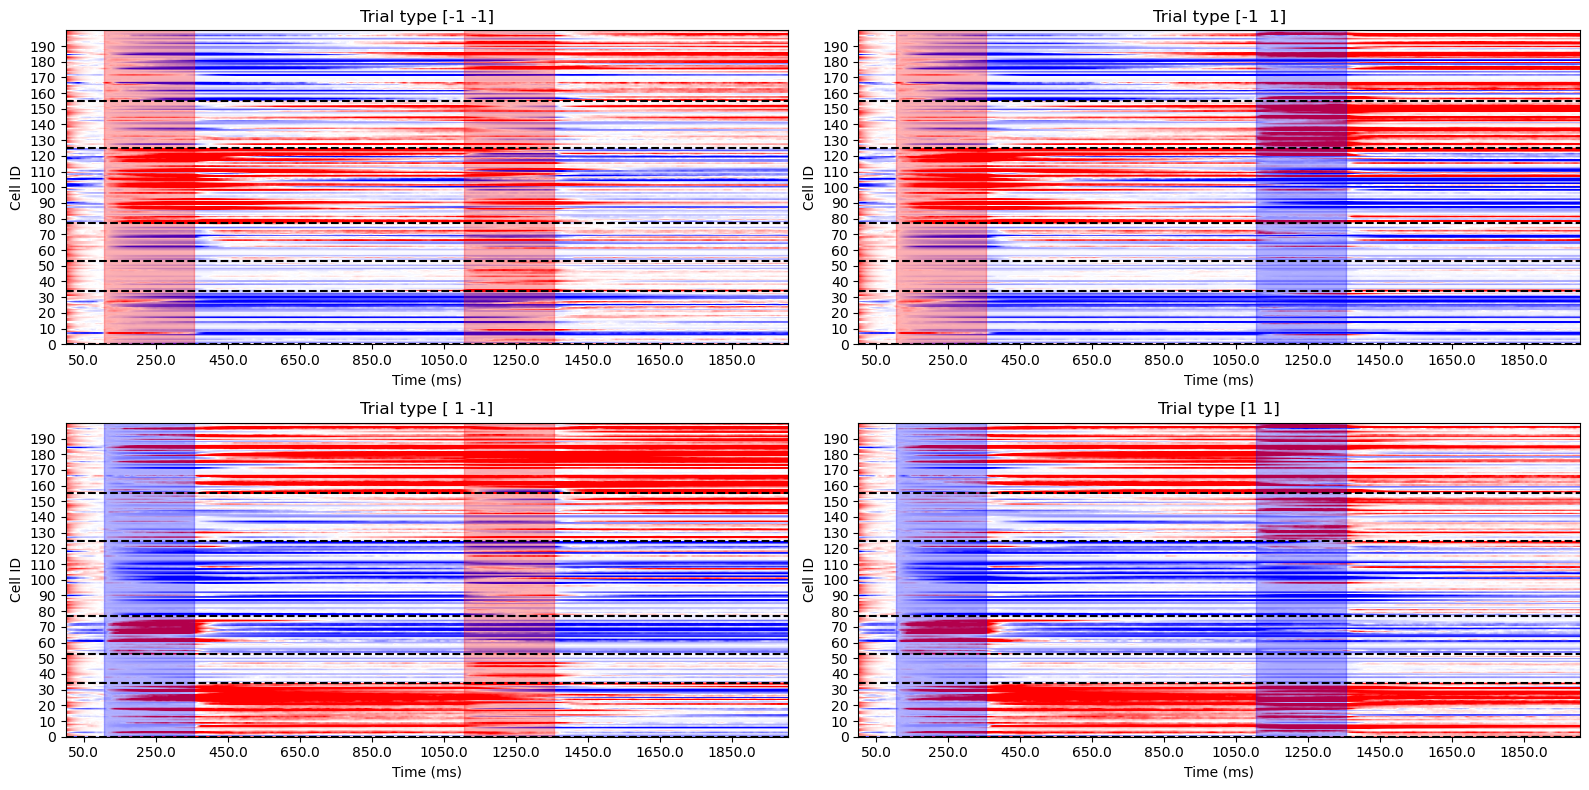

In [50]:
plot_rates_by_cluster(model_name, condn_phrase, condn_num, labels, rates_data = rates_data)

### Embedding raw (graph dist + non-normalized rate dist)

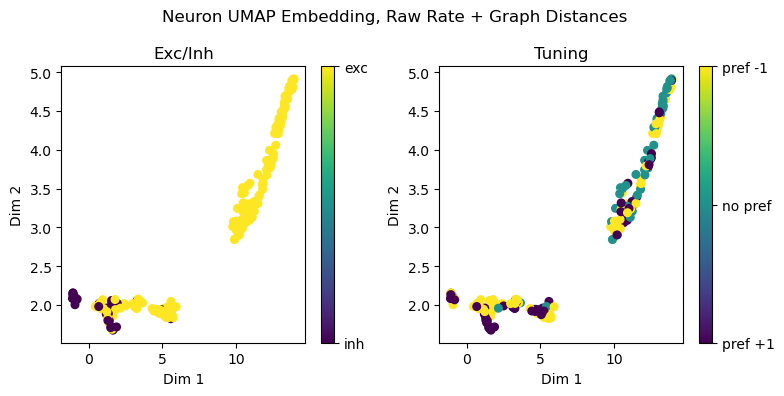

In [25]:
plot_embedding_exc_tuning(embedding_raw, exc, tuning, "Raw Rate + Graph Distances")

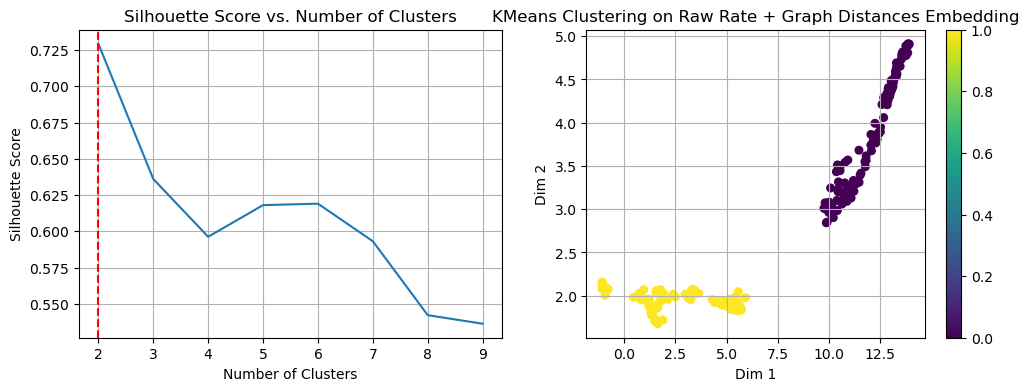

In [51]:
best_k, labels = plot_kmeans_clusters(embedding_raw, "Raw Rate + Graph Distances")

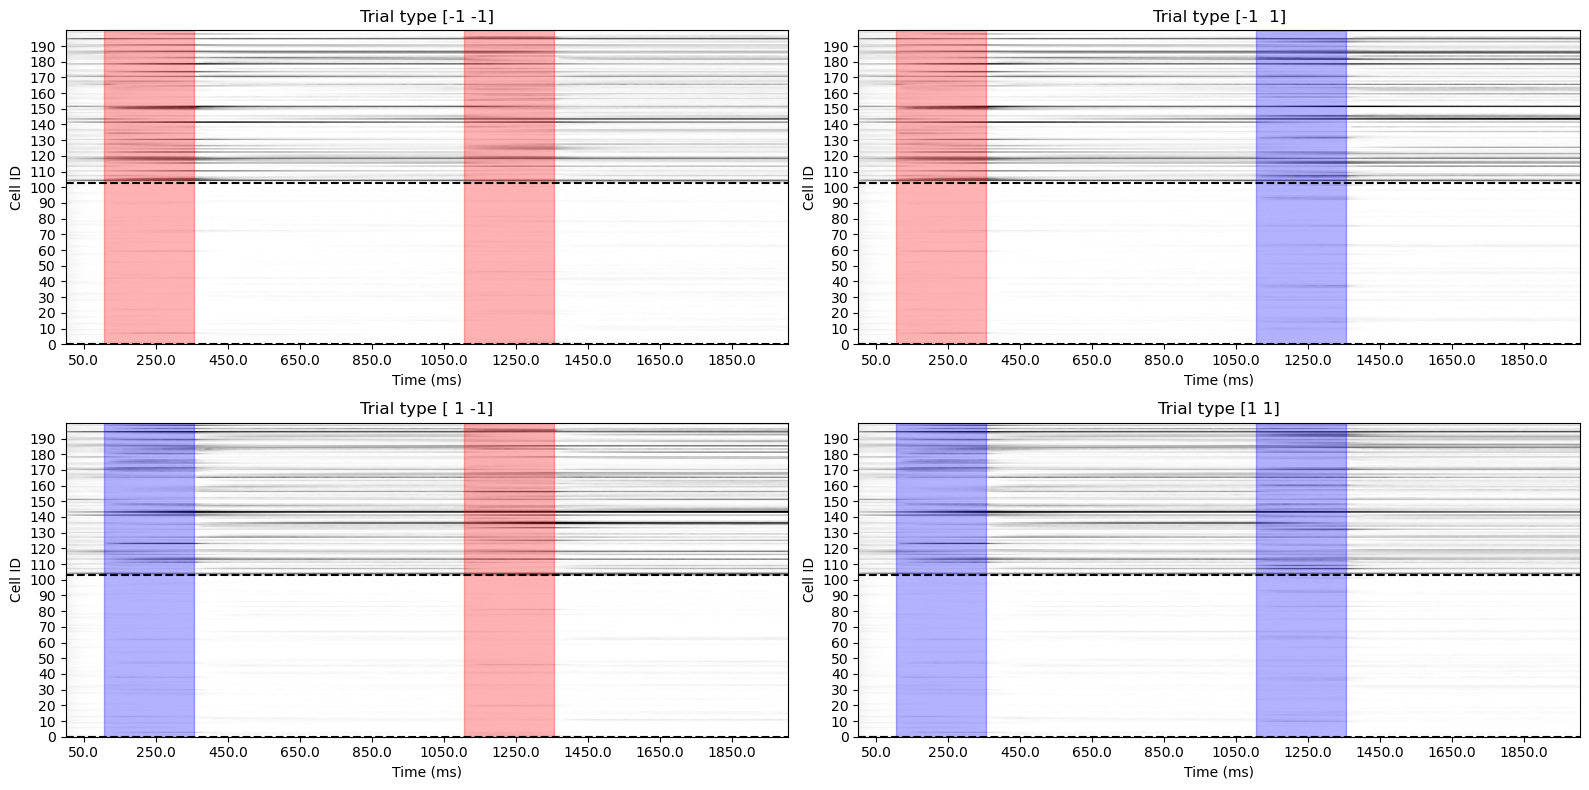

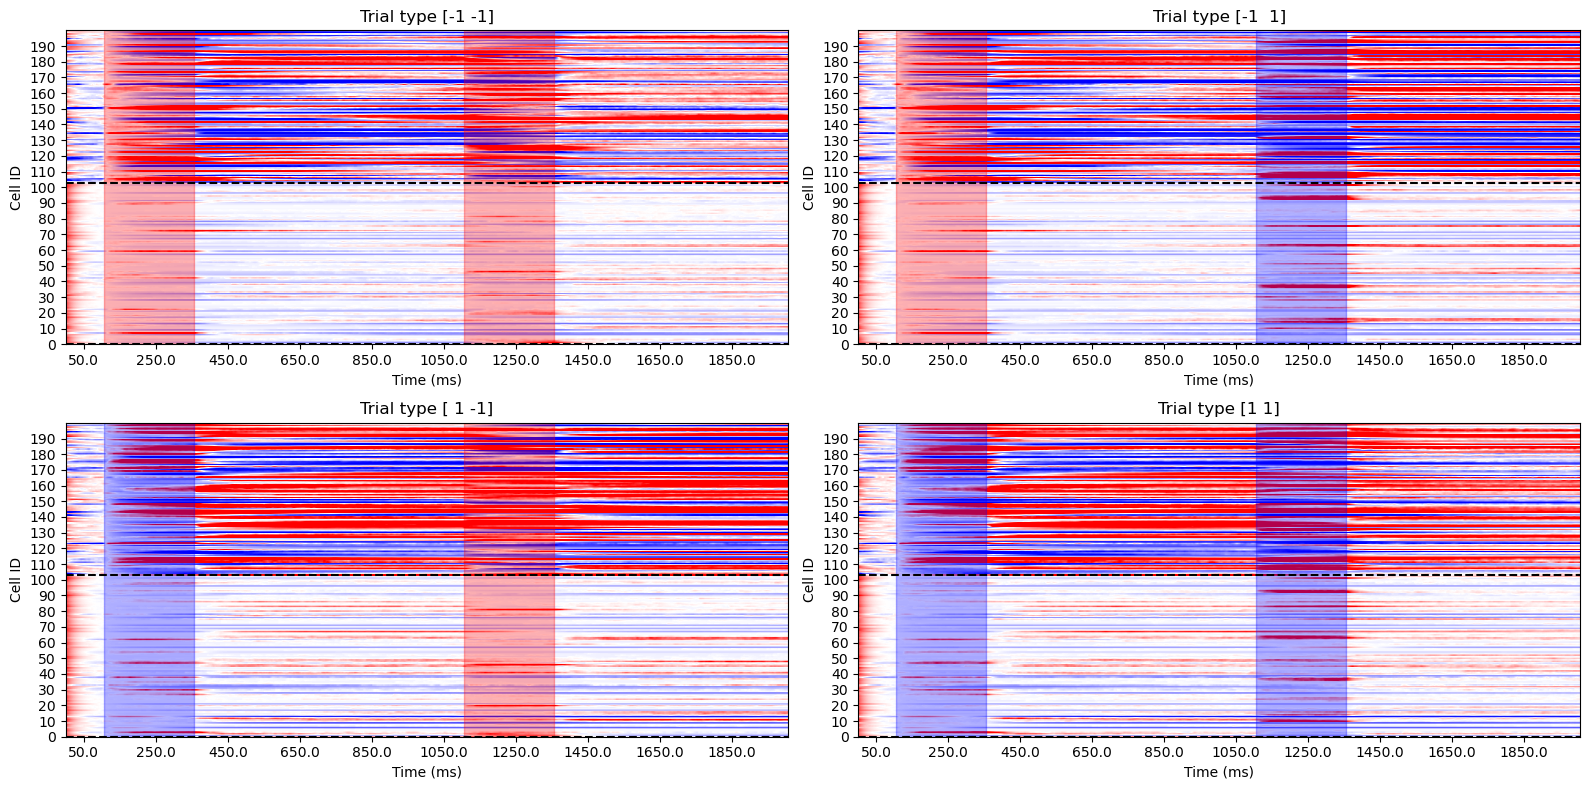

In [52]:
plot_rates_by_cluster(model_name, condn_phrase, condn_num, labels, rates_data = rates_data)

### Embedding rate norm (rate dist only, norm)

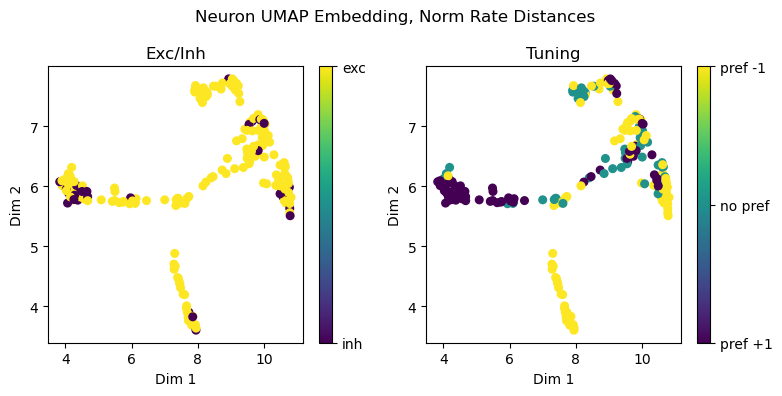

In [26]:
plot_embedding_exc_tuning(embedding_rate_norm, exc, tuning, "Norm Rate Distances")

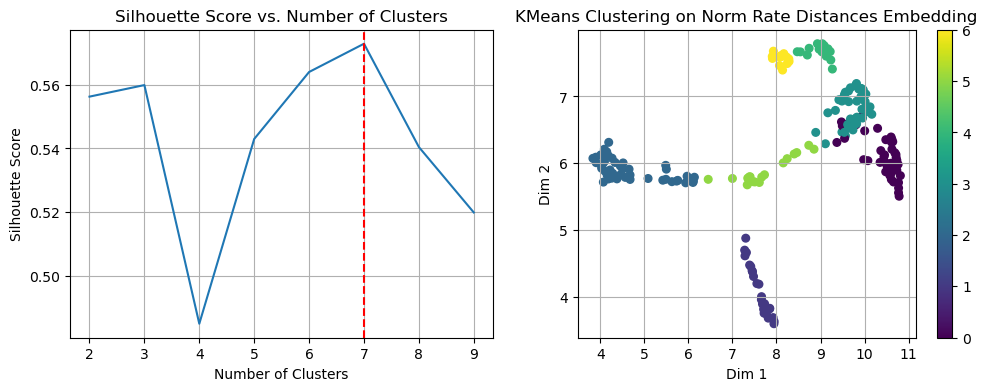

In [53]:
best_k, labels = plot_kmeans_clusters(embedding_rate_norm, "Norm Rate Distances")

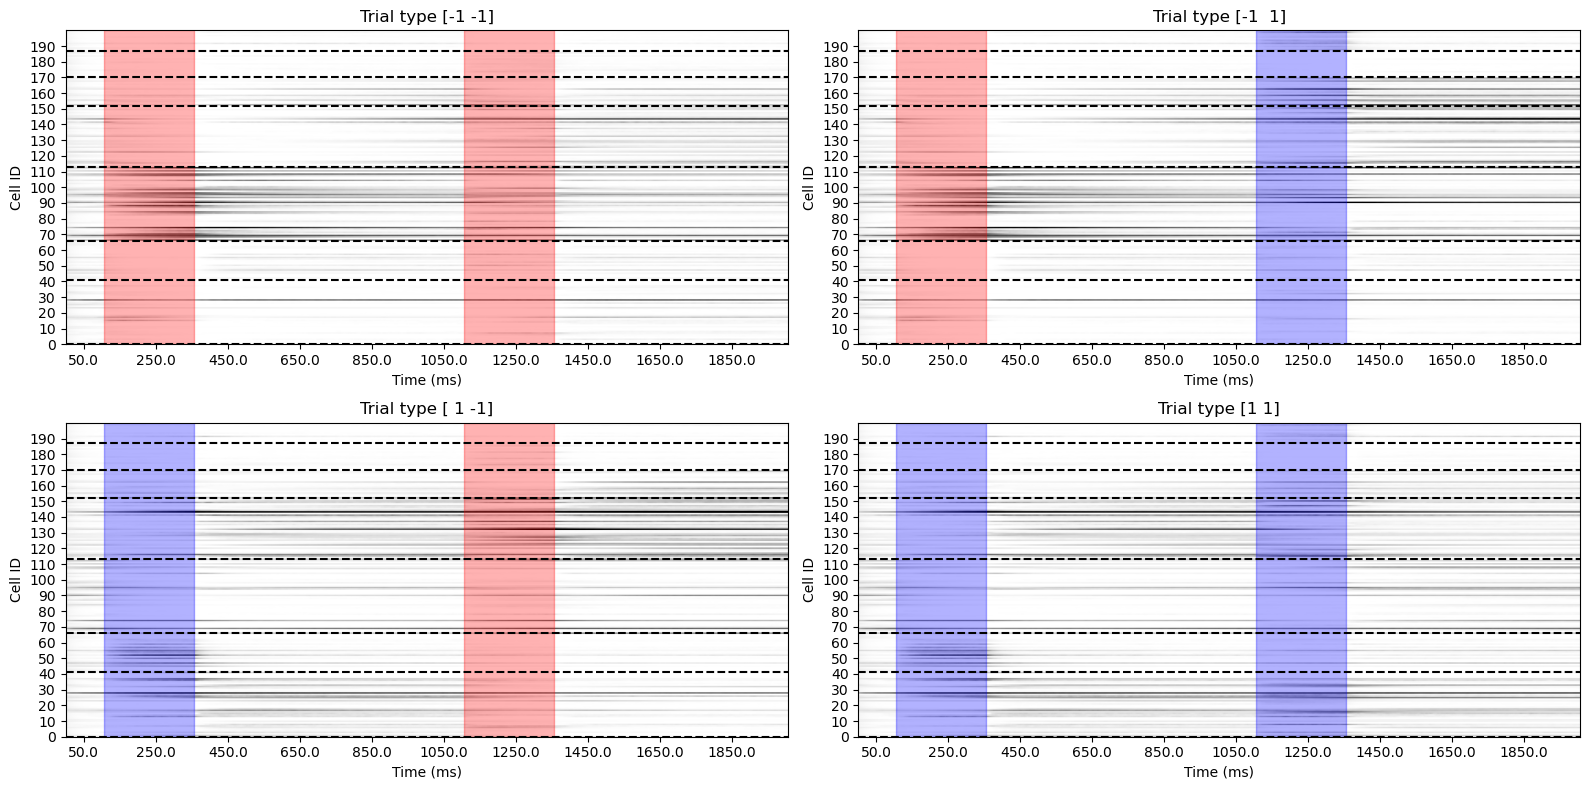

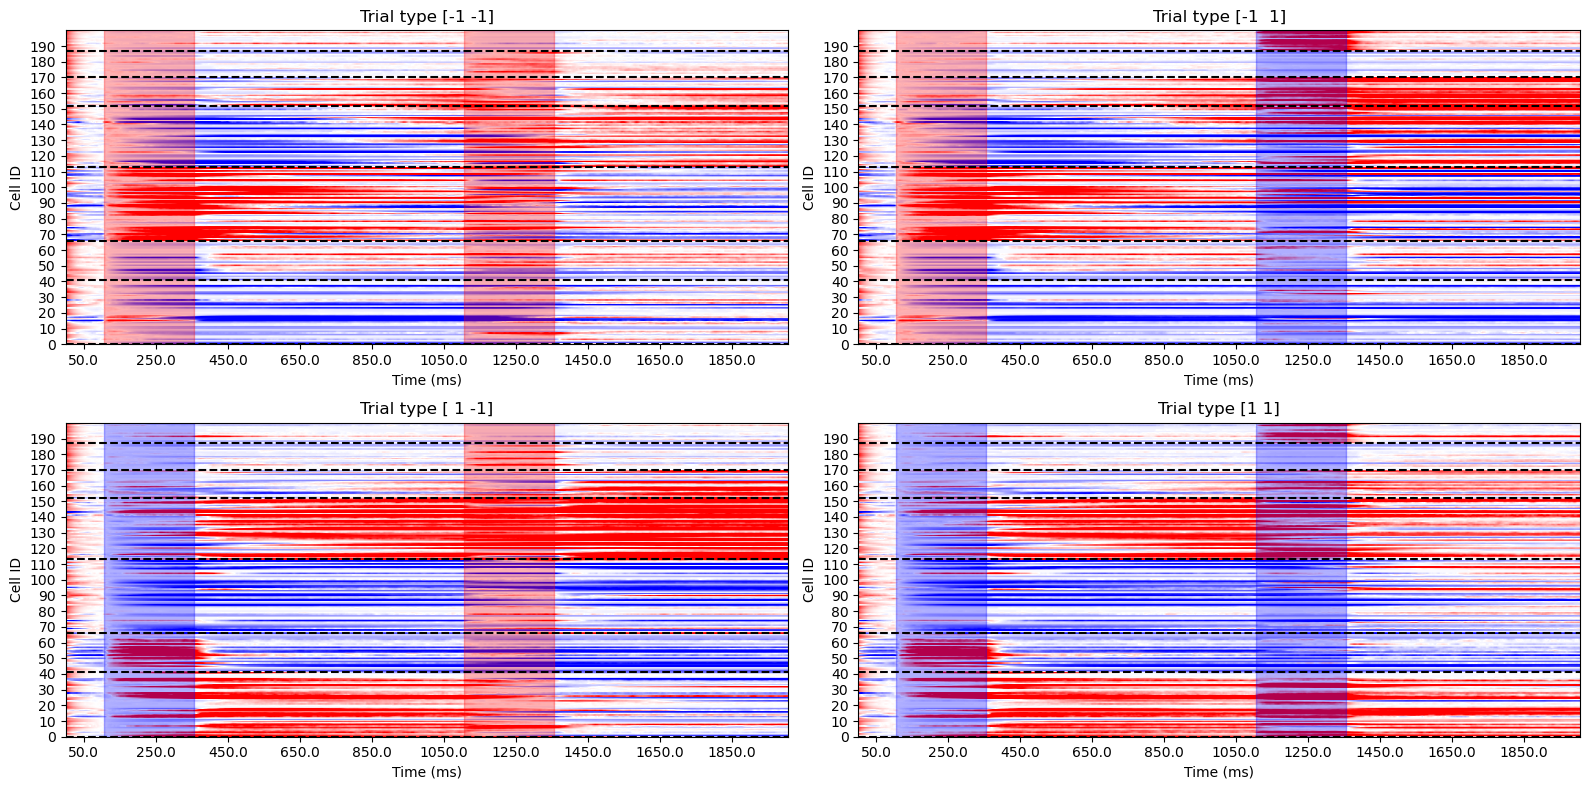

In [54]:
plot_rates_by_cluster(model_name, condn_phrase, condn_num, labels, rates_data = rates_data)

### Embedding rate raw (rate dist only, raw)

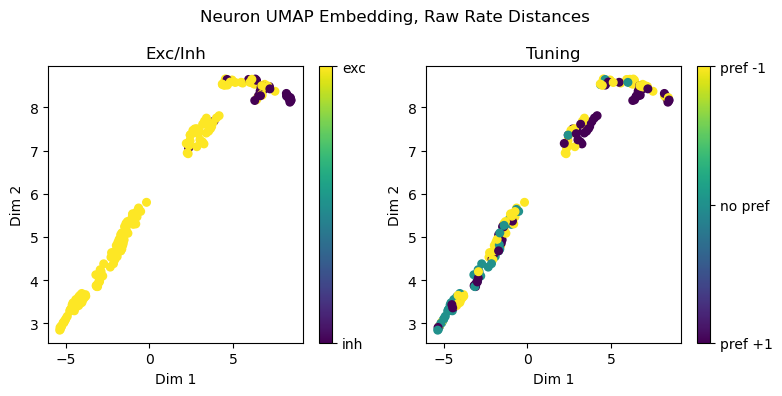

In [27]:
plot_embedding_exc_tuning(embedding_rate_raw, exc, tuning, "Raw Rate Distances")

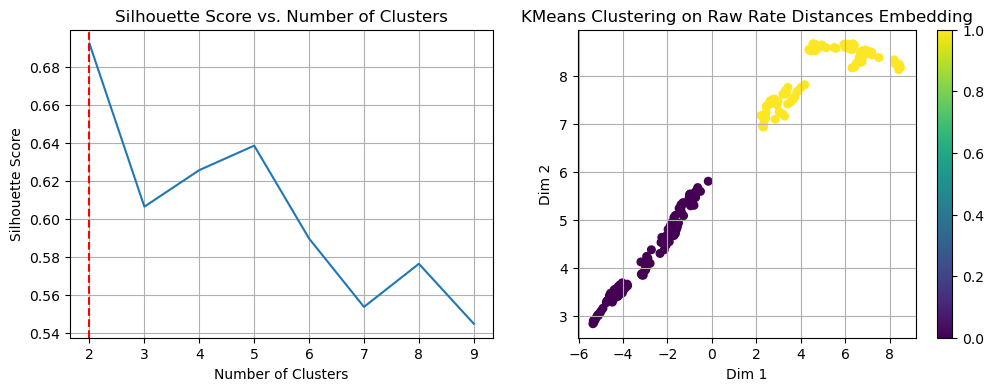

In [55]:
best_k, labels = plot_kmeans_clusters(embedding_rate_raw, "Raw Rate Distances")

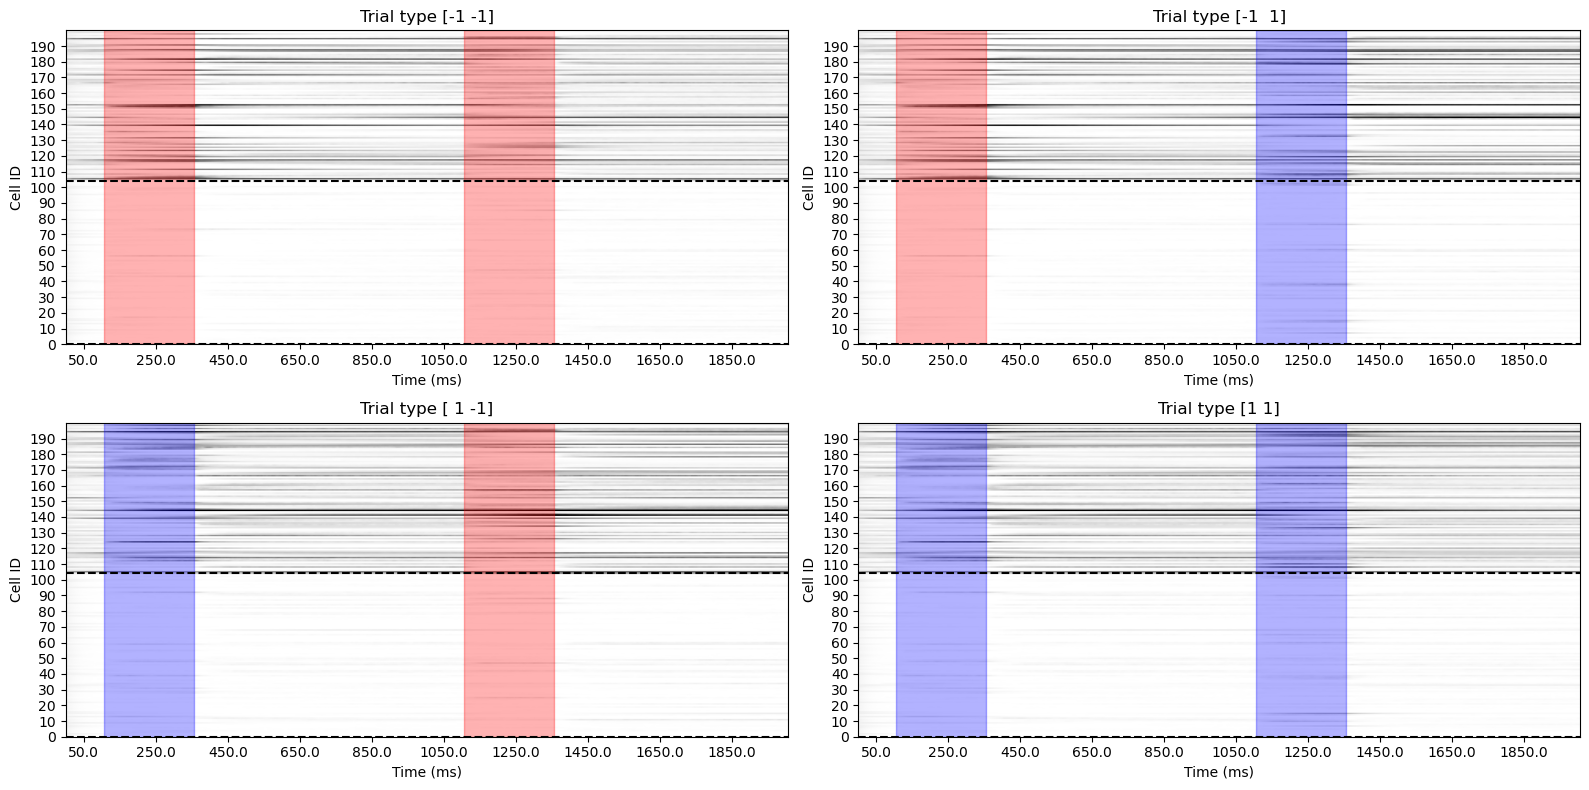

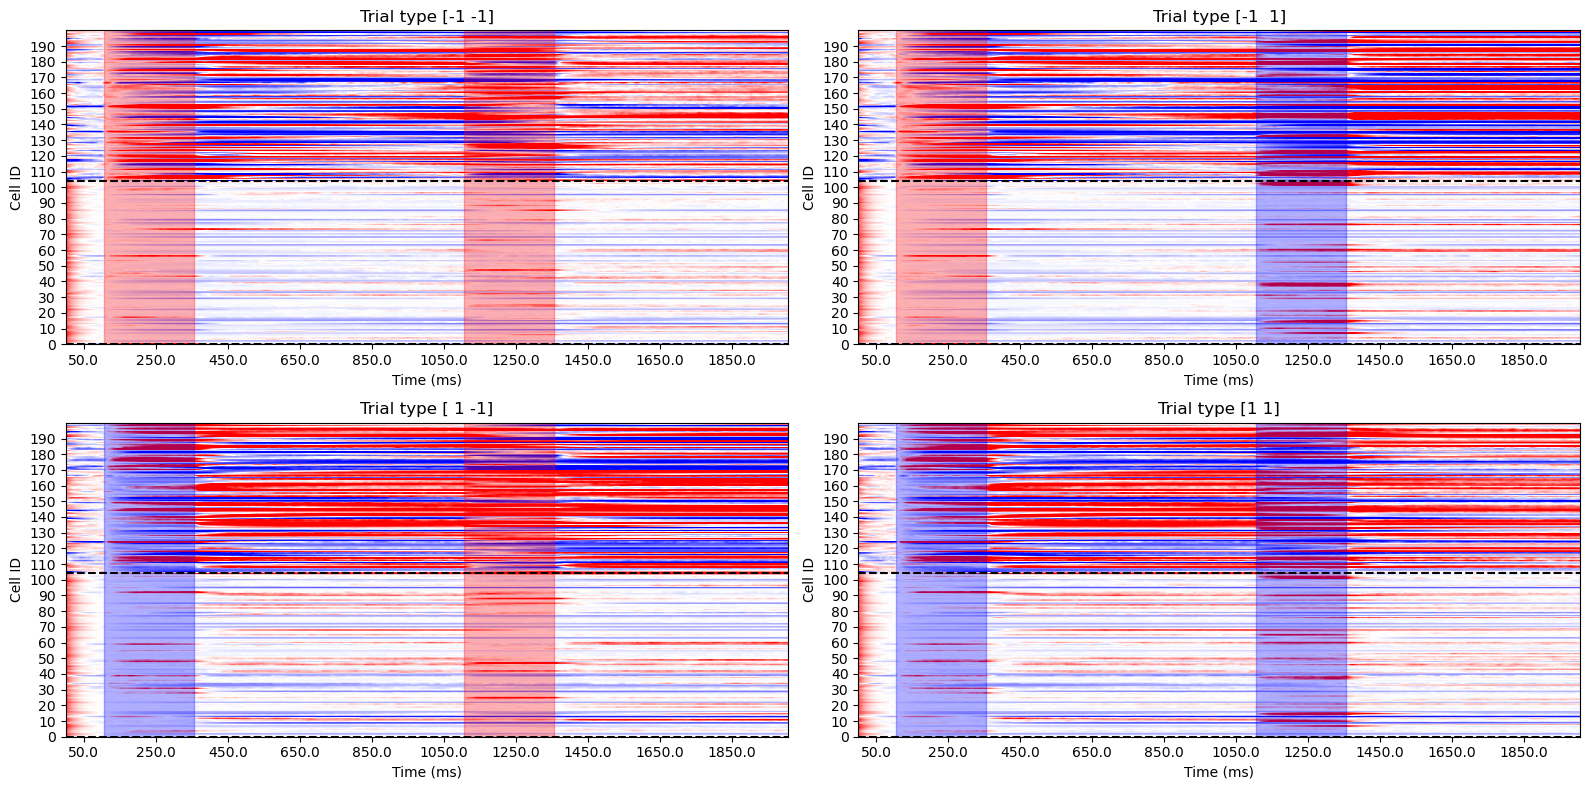

In [56]:
plot_rates_by_cluster(model_name, condn_phrase, condn_num, labels, rates_data = rates_data)

### Control

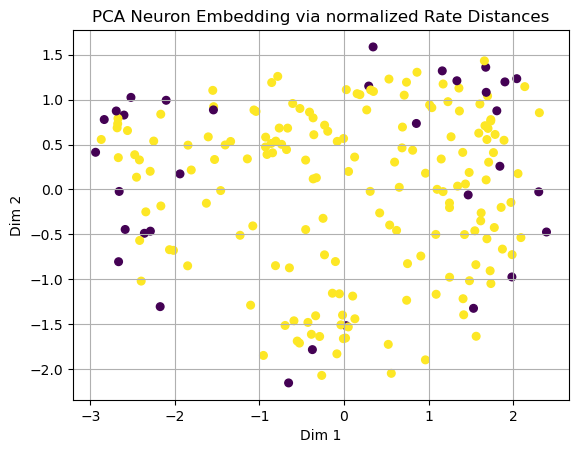

In [29]:
from sklearn.decomposition import PCA

def embed_pca(dist_matrix, dim=2):
    pca = PCA(n_components=dim)
    embedding = pca.fit_transform(dist_matrix)
    return embedding

embedding_rate_pca = embed_pca(rate_dist_norm, dim=2)
plt.scatter(embedding_rate_pca[:, 0], embedding_rate_pca[:, 1], c=exc, s=30)
plt.title("PCA Neuron Embedding via normalized Rate Distances")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()